# Week 4: Group comparison and evaluation (Group + Individual)

In Week 4, you will return to group work to compare different approaches and evaluate their performance.

## Objective

The aims of this stage are to:
- compare estimation and control strategies across the group,
- assess robustness and generalisation,
- develop a critical understanding of the strengths and limitations of different approaches.

## Group tasks

As a group, you should:
1. **Compare approaches**  
   Discuss differences in:
   - estimation methods,
   - control strategies,
   - design assumptions,
   - evaluation criteria.

2. **Standardise testing**  
   Ensure that all group members evaluate their methods under comparable conditions (e.g. initial states, input patterns, and time horizons), so that comparisons are meaningful and fair.

3. **Test robustness**  
   Evaluate performance under:
   - increased noise,
   - different stimulation patterns,
   - variations in system behaviour,
   - parameter perturbations where appropriate.

4. **Analyse results**  
   Identify:
   - which approaches perform best,
   - under what conditions,
   - what trade-offs emerge,
   - and why differences arise.

## Deliverables

### Group presentation
**10 marks**  
**Presentation session:** Tuesday 9 June, 9–11am

Your presentation should clearly communicate:
- the overall problem setup,
- the approaches explored within the group,
- comparative results,
- robustness and limitations,
- key insights and lessons learned.

Each group member is expected to contribute to both the work and the presentation.

Presentations should:
- remain concise and visually clear,
- prioritise interpretation over large quantities of plots,
- discuss both successful and unsuccessful results honestly.

You may structure the presentation in any clear and logical way.

### Individual final report
**40 marks**  
**Due:** Friday 12 June, 4pm BST

Your final report should include:
- a description of your estimation and control approach,
- experimental design and evaluation methodology,
- results and performance analysis,
- discussion of strengths and limitations,
- reflections on alternative approaches (including those explored within your group),
- suggestions for future improvements.

The report must not exceed **10 pages total**, including figures and appendix material.  
A report length of approximately **8 pages** is recommended.

Reports should be concise, well structured, and focused on reasoning and evaluation rather than exhaustive presentation of results.

Strong evaluations include both successful results and meaningful failure cases.

---

## Control interface

To make closed-loop testing consistent, your controller should follow the interface below.

Your function should take:
- the observations collected so far,
- a description of the target behaviour,

and return the next input vector \(u(t)\) to apply to the system.

You are free to implement any control strategy internally, but the function must return a command vector of the correct shape.

In [160]:
def control_policy(observations, target):
    """
    Placeholder for your own control strategy.

    Parameters
    ----------
    observations : list or array
        Past observed outputs.
    target : object
        Your chosen target description.

    Returns
    -------
    u : array of shape (U,)
        Command vector to apply at the next time step.
    """
    raise NotImplementedError("Implement your control strategy here.")

## Running a closed-loop experiment

The following helper function illustrates how to run the simulator in closed loop.

At each time step:

1. the current observation is measured,

2. the controller generates an input based on past observations,

3. the input is applied to the system,

4. the resulting observations and commands are stored.

This provides a simple framework for testing and comparing different control strategies.

In [161]:
def run_closed_loop(brain_factory, controller, target, T=100):
    """
    Run the simulator in closed loop using a user-defined controller.
    """
    brain = brain_factory()
    observations = []
    commands = []

    for _ in range(T):
        y = brain.measure()
        u = controller(np.array(observations), target)
        brain.next_state(u)

        observations.append(y)
        commands.append(u)

    return np.vstack(observations), np.vstack(commands)

## Standardising experiments

The following wrapper provides a simple standard interface for running experiments.

When comparing approaches within your group, you should aim to use:
- the same experimental duration,
- the same target definitions,
- and comparable initial conditions where possible.

Standardising evaluation conditions makes comparisons more meaningful and easier to interpret.

In [162]:
def run_experiment(brain_factory, controller, target, T=100):
    """
    Standard wrapper for comparing controllers under shared conditions.
    Groups should use the SAME test conditions when comparing approaches.
    """
    observations, commands = run_closed_loop(brain_factory, controller, target, T=T)
    return observations, commands

---
## Final remarks

The final stage of the project is not only about achieving good performance, but also about demonstrating understanding.

Strong submissions will demonstrate:
- clear engineering reasoning,
- careful experimental design,
- thoughtful evaluation,
- critical assessment of both successes and limitations,
- and well-structured technical communication.

Complexity alone is not rewarded. Carefully justified and thoroughly analysed approaches are preferable to complicated but poorly understood methods.


In [245]:
import numpy as np, torch, glob
import matplotlib.pyplot as plt
from BMI_and_Hand import BMI_and_Hand, load_ann
from GG4 import Brain

def brain_factory(seed=0):
    return BMI_and_Hand(Brain(seed))

L1 = L2 = 30.0
bmi = brain_factory()
print("neural dim:", np.array(bmi.next_state(np.zeros(2))).shape, " hand:", bmi.hand_pos)

neural dim: (16,)  hand: [60.  0.]


In [246]:
def wrap_pi(x):
    return (x + np.pi) % (2*np.pi) - np.pi

def forward_kin(ts, te):
    x = L1*np.cos(ts) + L2*np.cos(ts+te)
    y = L1*np.sin(ts) + L2*np.sin(ts+te)
    return np.array([x, y])

def inverse_kin(hand, prev_ts=0.0, prev_te=0.5):
    """只取肘角为正的解(因为elbow-极弱, 单向弯肘)"""
    x, y = hand
    r2 = x*x + y*y
    cos_e = np.clip((r2 - L1*L1 - L2*L2)/(2*L1*L2), -1, 1)
    te = np.arccos(cos_e)          # 正解
    k1, k2 = L1 + L2*np.cos(te), L2*np.sin(te)
    ts = np.arctan2(y, x) - np.arctan2(k2, k1)
    return ts, te

def target_in_workspace(tgt):
    r = np.hypot(*tgt)
    return 1.0 < r < 59.5          # 太靠圆心或圆外都不可达

In [247]:
class DualFreqController:
    """
    ch0 叠加 肩频 + 肘频, 每个频率分量的 amp 按对应关节的误差独立调整.
    这正是 '每块肌肉不同amp、需要分配' 的实现.
    """
    # 频率表(实测)
    P_SHOULDER_POS = 16
    P_SHOULDER_NEG = 8
    P_ELBOW_POS    = 5

    def __init__(self, ts_tol=0.04, te_tol=0.04,
                 k_shoulder=5.0, k_elbow=9.0,
                 amp_max_sh=0.20, amp_max_el=0.20, off=0.5):
        self.t = 0
        self.ts_tol, self.te_tol = ts_tol, te_tol
        self.k_sh, self.k_el = k_shoulder, k_elbow
        self.amp_max_sh, self.amp_max_el = amp_max_sh, amp_max_el
        self.off = off
        self.reach_stop = reach_stop
        self.ts_goal = self.te_goal = None
        self.target = None
        self.last_u = np.array([0.5, 0.5])

    def set_target(self, tgt):
        self.target = np.asarray(tgt, float)
        self.ts_goal, self.te_goal = inverse_kin(self.target)

    def __call__(self, hand):
        hand = np.asarray(hand, dtype=float)
        dist = np.linalg.norm(hand - self.target)
        if dist < self.reach_stop:
            self.last_u = np.array([0.5, 0.5]); return self.last_u

        # 极坐标: 当前 vs 目标
        r   = np.hypot(*hand)
        phi = np.arctan2(hand[1], hand[0])
        r_goal   = np.hypot(*self.target)
        phi_goal = np.arctan2(self.target[1], self.target[0])
        e_phi = wrap_pi(phi_goal - phi)     # 角度误差
        e_r   = r_goal - r                  # 半径误差(正=要往外, 负=要往内)

        PHI_TOL = 0.06      # 角度对准阈值(弧度, ~3.4度)
        u0 = self.off

        if abs(e_phi) > PHI_TOL:
            # ---- 阶段1: 只转角度 ----
            # e_phi>0 需逆时针(肩+, p16); <0 需顺时针(肩-, p8)
            p_sh = self.P_SHOULDER_POS if e_phi > 0 else self.P_SHOULDER_NEG
            amp_sh = self.amp_max_sh * np.tanh(self.k_sh * abs(e_phi))
            u0 += amp_sh * np.sin(2*np.pi*self.t / p_sh)
        else:
            # ---- 阶段2: 角度对准了, 只调半径(弯/伸肘) ----
            # e_r<0 要往内收(弯肘, 正相 p5); e_r>0 要往外伸(伸肘, 反相 p5)
            p_el = self.P_ELBOW_POS
            amp_el = self.amp_max_el * np.tanh(self.k_el * abs(e_r) / 10.0)
            sign_el = -1.0 if e_r > 0 else 1.0   # 往外伸=反相, 往内收=正相
            u0 += sign_el * amp_el * np.sin(2*np.pi*self.t / p_el)

        u = np.clip(np.array([u0, 0.5]), 0.0, 1.0)
        self.t += 1; self.last_u = u
        return u

处理顺序: [((50, 20), 53.9), ((30, 30), 42.4), ((-25, 30), 39.1), ((10, -25), 26.9)]


NameError: name 'reach_stop' is not defined

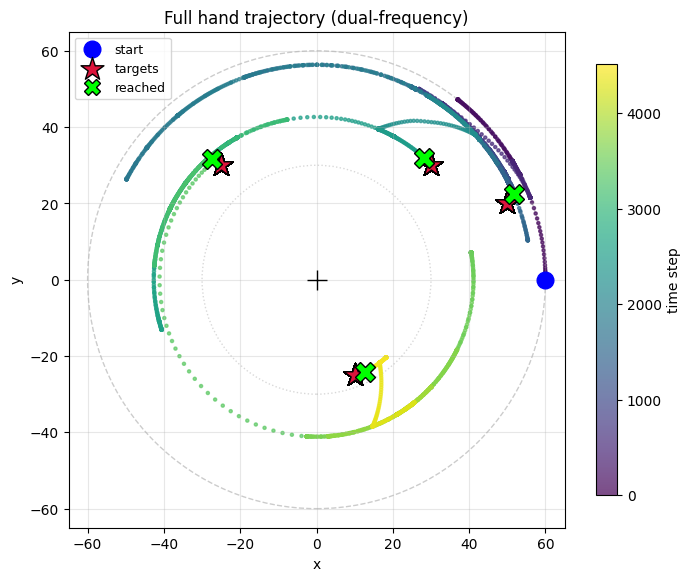

In [249]:
fig, ax = plt.subplots(figsize=(8,8))
ax.set_xlim(-65,65); ax.set_ylim(-65,65); ax.set_aspect('equal')
ax.add_patch(plt.Circle((0,0),60,fill=False,ls='--',color='gray',alpha=0.4))
ax.add_patch(plt.Circle((0,0),30,fill=False,ls=':',color='gray',alpha=0.3))
ax.grid(alpha=0.3); ax.set_title("Full hand trajectory (dual-frequency)")
ax.set_xlabel("x"); ax.set_ylabel("y")

n = len(hand_log)
sc = ax.scatter(hand_log[:,0], hand_log[:,1], c=np.arange(n), cmap='viridis', s=5, alpha=0.7)
ax.plot(hand_log[0,0], hand_log[0,1], 'o', color='blue', ms=12, label='start')
ax.scatter(target_log[:,0], target_log[:,1], marker='*', color='crimson',
           s=300, label='targets', zorder=5, edgecolor='k')
for idx, tgt in reached:
    ax.plot(hand_log[idx,0], hand_log[idx,1], 'X', color='lime', ms=15,
            zorder=6, markeredgecolor='k')
ax.plot([],[],'X',color='lime',ms=12,markeredgecolor='k',label='reached')
ax.plot(0,0,'k+',ms=15); ax.legend(loc='upper left', fontsize=9)
plt.colorbar(sc, ax=ax, label='time step', shrink=0.7)
plt.savefig("trajectory.png", dpi=120, bbox_inches='tight'); plt.show()

已保存 reaching.gif (1128 帧)


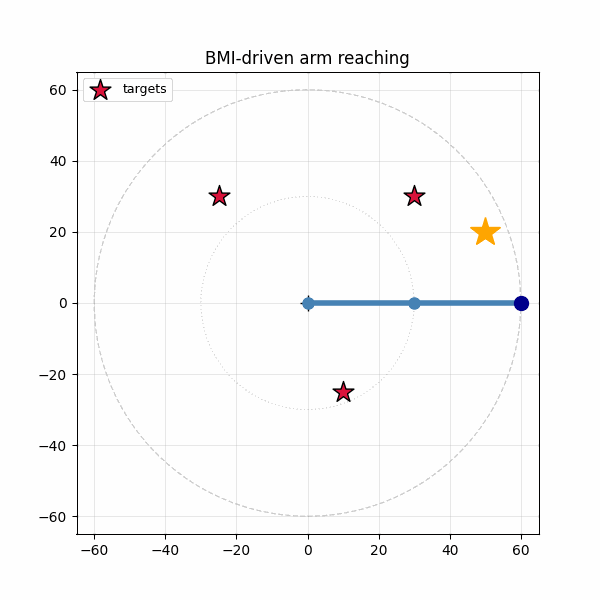

In [250]:
# ============================================================
# 生成 GIF: 双连杆手臂追踪 target 动画
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

L1 = L2 = 30.0

def arm_pts(hand):
    x, y = hand
    r2 = x*x + y*y
    cos_e = np.clip((r2 - L1*L1 - L2*L2)/(2*L1*L2), -1, 1)
    te = np.arccos(cos_e)
    k1, k2 = L1 + L2*np.cos(te), L2*np.sin(te)
    ts = np.arctan2(y, x) - np.arctan2(k2, k1)
    return (np.array([0.0, 0.0]),
            np.array([L1*np.cos(ts), L1*np.sin(ts)]),
            np.array([x, y]))

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-65, 65); ax.set_ylim(-65, 65); ax.set_aspect('equal')
ax.set_title("BMI-driven arm reaching"); ax.grid(alpha=0.3)
ax.add_patch(plt.Circle((0, 0), 60, fill=False, ls='--', color='gray', alpha=0.4))
ax.add_patch(plt.Circle((0, 0), 30, fill=False, ls=':', color='gray', alpha=0.3))
ax.plot(0, 0, 'k+', ms=12)

uniq_t = np.unique(target_log, axis=0)
ax.scatter(uniq_t[:, 0], uniq_t[:, 1], marker='*', color='crimson',
           s=250, zorder=3, edgecolor='k', label='targets')

arm_line,  = ax.plot([], [], 'o-', lw=4, color='steelblue', ms=8)
hand_dot,  = ax.plot([], [], 'o', color='darkblue', ms=10)
cur_target,= ax.plot([], [], '*', color='orange', ms=22, zorder=4)
trail,     = ax.plot([], [], '-', color='orange', lw=1, alpha=0.5)
ax.legend(loc='upper left', fontsize=9)

STEP = 4
n_frames = len(hand_log) // STEP

def animate(i):
    k = min(i*STEP, len(hand_log)-1)
    s, e, h = arm_pts(hand_log[k])
    arm_line.set_data([s[0], e[0], h[0]], [s[1], e[1], h[1]])
    hand_dot.set_data([h[0]], [h[1]])
    cur_target.set_data([target_log[k][0]], [target_log[k][1]])
    trail.set_data(hand_log[:k+1, 0], hand_log[:k+1, 1])
    return arm_line, hand_dot, cur_target, trail

anim = FuncAnimation(fig, animate, frames=n_frames, interval=40, blit=True)
anim.save("reaching.gif", writer=PillowWriter(fps=25))
plt.close()
print(f"已保存 reaching.gif ({n_frames} 帧)")
Image("reaching.gif")

处理顺序: [((50, 20), 53.9), ((30, 30), 42.4), ((-25, 30), 39.1), ((10, -25), 26.9)]

到达: 4 / 4
  step374: [50. 20.] 误差2.80
  step978: [30. 30.] 误差2.80
  step1072: [-25.  30.] 误差2.97
  step2457: [ 10. -25.] 误差2.92


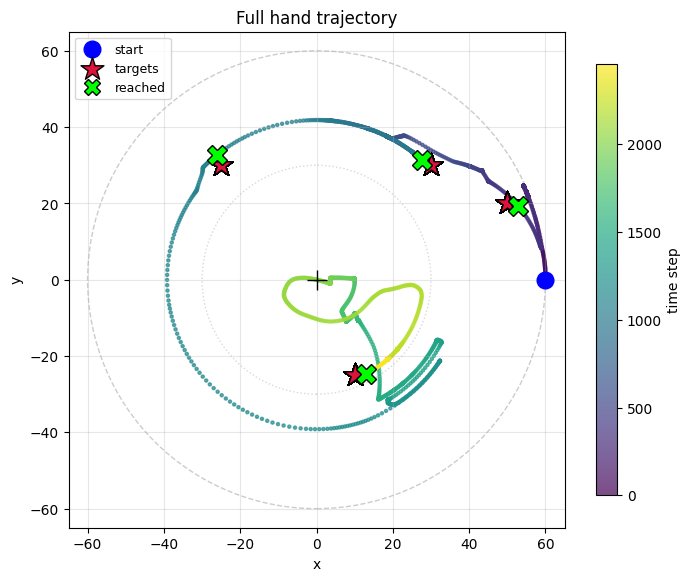

已保存 reaching.gif (614 帧)


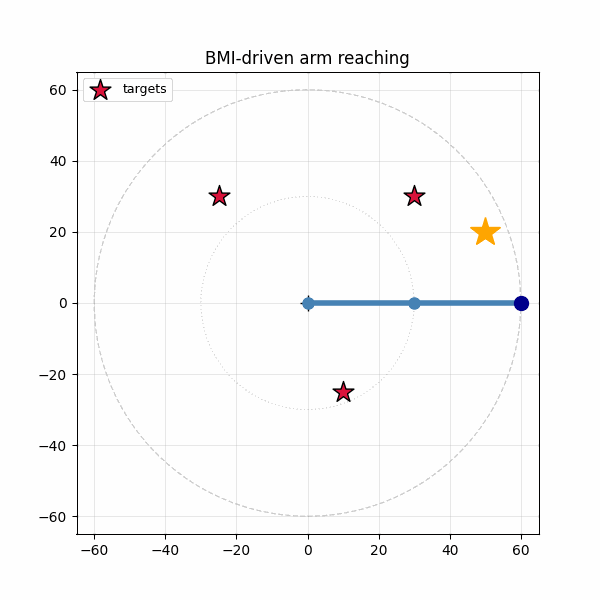

In [251]:
# ============================================================
# 一整个 cell: 控制器 + 运行 + 轨迹图 + GIF
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

L1 = L2 = 30.0

# ---------- 运动学 ----------
def inverse_kin(hand):
    x, y = hand
    r2 = x*x + y*y
    cos_e = np.clip((r2 - L1*L1 - L2*L2)/(2*L1*L2), -1, 1)
    te = np.arccos(cos_e)
    k1, k2 = L1 + L2*np.cos(te), L2*np.sin(te)
    ts = np.arctan2(y, x) - np.arctan2(k2, k1)
    return ts, te

def target_in_workspace(tgt):
    r = np.hypot(*tgt)
    return 1.0 < r < 59.5

def arm_pts(hand):
    ts, te = inverse_kin(hand)
    return (np.array([0.0, 0.0]),
            np.array([L1*np.cos(ts), L1*np.sin(ts)]),
            np.array([hand[0], hand[1]]))

# ---------- 控制器 ----------
class DualFreqController:
    P_SHOULDER_POS = 16
    P_SHOULDER_NEG = 8
    P_ELBOW_POS    = 5

    def __init__(self, ts_tol=0.04, te_tol=0.04,
                 k_shoulder=4.0, k_elbow=9.0,
                 amp_max_sh=0.20, amp_max_el=0.28, off=0.5):
        self.t = 0
        self.ts_tol, self.te_tol = ts_tol, te_tol
        self.k_sh, self.k_el = k_shoulder, k_elbow
        self.amp_max_sh, self.amp_max_el = amp_max_sh, amp_max_el
        self.off = off
        self.ts_goal = self.te_goal = None
        self.last_u = np.array([0.5, 0.5])

    def set_target(self, tgt):
        self.ts_goal, self.te_goal = inverse_kin(np.asarray(tgt, float))

    def __call__(self, hand):
        ts, te = inverse_kin(hand)
        e_ts = (self.ts_goal - ts + np.pi) % (2*np.pi) - np.pi
        e_te = self.te_goal - te

        if abs(e_ts) < self.ts_tol and abs(e_te) < self.te_tol:
            self.last_u = np.array([0.5, 0.5]); return self.last_u

        if abs(e_ts) > self.ts_tol:
            p_sh = self.P_SHOULDER_POS if e_ts > 0 else self.P_SHOULDER_NEG
            amp_sh = self.amp_max_sh * np.tanh(self.k_sh * abs(e_ts))
        else:
            p_sh, amp_sh = self.P_SHOULDER_POS, 0.0

        if abs(e_te) > self.te_tol:
            p_el = self.P_ELBOW_POS
            amp_el = self.amp_max_el * np.tanh(self.k_el * abs(e_te))
            sign_el = 1.0 if e_te > 0 else -1.0
        else:
            p_el, amp_el, sign_el = self.P_ELBOW_POS, 0.0, 1.0

        u0 = self.off
        u0 += amp_sh * np.sin(2*np.pi*self.t / p_sh)
        u0 += sign_el * amp_el * np.sin(2*np.pi*self.t / p_el)
        u = np.clip([u0, 0.5], 0.0, 1.0)
        self.t += 1; self.last_u = u
        return u

# ---------- 运行 ----------
def run_reaching(targets, max_steps=1500, reach_tol=3.0, seed=0):
    bmi = brain_factory(seed)
    ctrl = DualFreqController()
    hand_log, target_log, u_log, err_log, reached = [], [], [], [], []
    for tgt in targets:
        tgt = np.asarray(tgt, float)
        ctrl.set_target(tgt)
        for _ in range(max_steps):
            hand = bmi.hand_pos.copy()
            u = ctrl(hand)
            bmi.next_state(u)
            hand_log.append(hand); target_log.append(tgt.copy())
            u_log.append(u.copy())
            err = np.linalg.norm(hand - tgt); err_log.append(err)
            if err < reach_tol:
                reached.append((len(hand_log)-1, tgt.copy())); break
    return (np.array(hand_log), np.array(target_log),
            np.array(u_log), np.array(err_log), reached)

raw = [(50, 20), (30, 30), (-25, 30), (10, -25)]
targets = sorted([t for t in raw if target_in_workspace(t)], key=lambda p: -np.hypot(*p))
print("处理顺序:", [(t, round(np.hypot(*t), 1)) for t in targets])

hand_log, target_log, u_log, err_log, reached = run_reaching(targets, seed=0)
print("\n到达:", len(reached), "/", len(targets))
for idx, tgt in reached:
    print(f"  step{idx}: {tgt.round(1)} 误差{err_log[idx]:.2f}")

# ---------- 轨迹图 ----------
fig, ax = plt.subplots(figsize=(8,8))
ax.set_xlim(-65,65); ax.set_ylim(-65,65); ax.set_aspect('equal')
ax.add_patch(plt.Circle((0,0),60,fill=False,ls='--',color='gray',alpha=0.4))
ax.add_patch(plt.Circle((0,0),30,fill=False,ls=':',color='gray',alpha=0.3))
ax.grid(alpha=0.3); ax.set_title("Full hand trajectory"); ax.set_xlabel("x"); ax.set_ylabel("y")
n = len(hand_log)
sc = ax.scatter(hand_log[:,0], hand_log[:,1], c=np.arange(n), cmap='viridis', s=5, alpha=0.7)
ax.plot(hand_log[0,0], hand_log[0,1], 'o', color='blue', ms=12, label='start')
ax.scatter(target_log[:,0], target_log[:,1], marker='*', color='crimson', s=300,
           label='targets', zorder=5, edgecolor='k')
for idx, tgt in reached:
    ax.plot(hand_log[idx,0], hand_log[idx,1], 'X', color='lime', ms=15, zorder=6, markeredgecolor='k')
ax.plot([],[],'X',color='lime',ms=12,markeredgecolor='k',label='reached')
ax.plot(0,0,'k+',ms=15); ax.legend(loc='upper left', fontsize=9)
plt.colorbar(sc, ax=ax, label='time step', shrink=0.7)
plt.savefig("trajectory.png", dpi=120, bbox_inches='tight'); plt.show()

# ---------- GIF ----------
fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlim(-65,65); ax.set_ylim(-65,65); ax.set_aspect('equal')
ax.set_title("BMI-driven arm reaching"); ax.grid(alpha=0.3)
ax.add_patch(plt.Circle((0,0),60,fill=False,ls='--',color='gray',alpha=0.4))
ax.add_patch(plt.Circle((0,0),30,fill=False,ls=':',color='gray',alpha=0.3))
ax.plot(0,0,'k+',ms=12)
uniq_t = np.unique(target_log, axis=0)
ax.scatter(uniq_t[:,0], uniq_t[:,1], marker='*', color='crimson', s=250,
           zorder=3, edgecolor='k', label='targets')
arm_line, = ax.plot([],[],'o-',lw=4,color='steelblue',ms=8)
hand_dot, = ax.plot([],[],'o',color='darkblue',ms=10)
cur_target,= ax.plot([],[],'*',color='orange',ms=22,zorder=4)
trail, = ax.plot([],[],'-',color='orange',lw=1,alpha=0.5)
ax.legend(loc='upper left', fontsize=9)
STEP = 4
n_frames = max(1, len(hand_log)//STEP)
def animate(i):
    k = min(i*STEP, len(hand_log)-1)
    s,e,h = arm_pts(hand_log[k])
    arm_line.set_data([s[0],e[0],h[0]],[s[1],e[1],h[1]])
    hand_dot.set_data([h[0]],[h[1]])
    cur_target.set_data([target_log[k][0]],[target_log[k][1]])
    trail.set_data(hand_log[:k+1,0], hand_log[:k+1,1])
    return arm_line, hand_dot, cur_target, trail
anim = FuncAnimation(fig, animate, frames=n_frames, interval=40, blit=True)
anim.save("reaching.gif", writer=PillowWriter(fps=25))
plt.close()
print(f"已保存 reaching.gif ({n_frames} 帧)")
Image("reaching.gif")

处理顺序: [((50, 20), 53.9), ((30, 30), 42.4), ((-25, 30), 39.1), ((10, -25), 26.9)]

到达: 4 / 4
  step116: [50. 20.] 误差2.93
  step332: [30. 30.] 误差2.63
  step391: [-25.  30.] 误差2.46
  step809: [ 10. -25.] 误差2.11


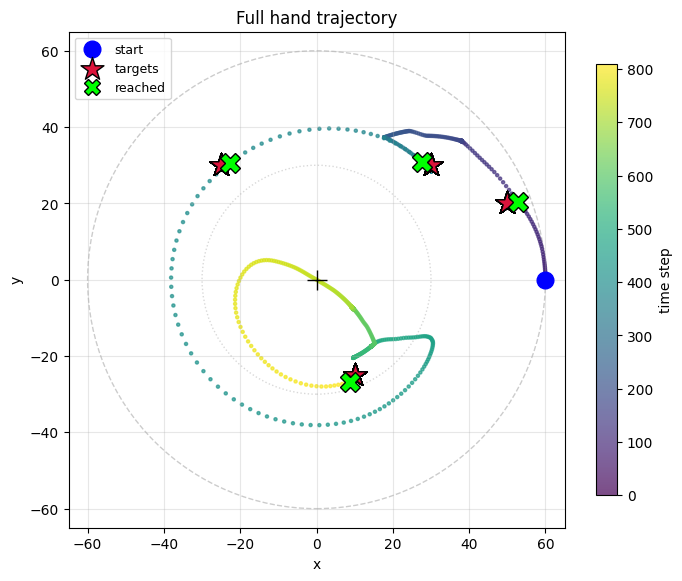

已保存 reaching.gif (202 帧)


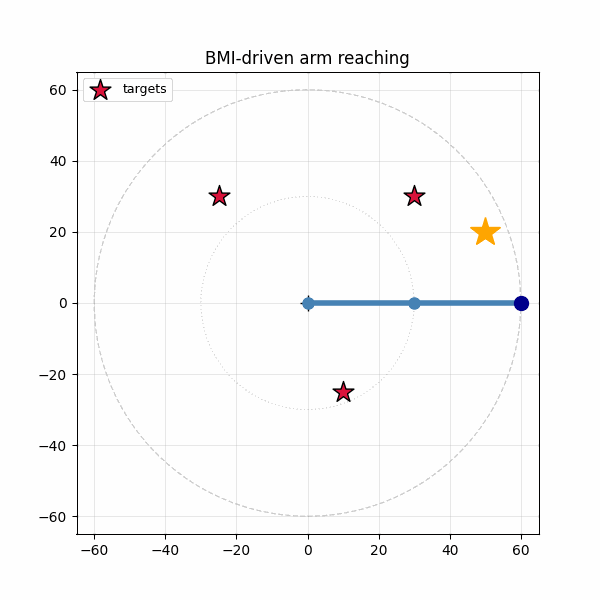

In [252]:
# ============================================================
# 一整个 cell: 控制器 + 运行 + 轨迹图 + GIF (原始4/4版)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

L1 = L2 = 30.0

# ---------- 运动学 ----------
def inverse_kin(hand):
    x, y = hand
    r2 = x*x + y*y
    cos_e = np.clip((r2 - L1*L1 - L2*L2)/(2*L1*L2), -1, 1)
    te = np.arccos(cos_e)
    k1, k2 = L1 + L2*np.cos(te), L2*np.sin(te)
    ts = np.arctan2(y, x) - np.arctan2(k2, k1)
    return ts, te

def target_in_workspace(tgt):
    r = np.hypot(*tgt)
    return 1.0 < r < 59.5

def arm_pts(hand):
    ts, te = inverse_kin(hand)
    return (np.array([0.0, 0.0]),
            np.array([L1*np.cos(ts), L1*np.sin(ts)]),
            np.array([hand[0], hand[1]]))

# ---------- 控制器 ----------
class DualFreqController:
    P_SHOULDER_POS = 16
    P_SHOULDER_NEG = 8
    P_ELBOW_POS    = 5

    def __init__(self, ts_tol=0.04, te_tol=0.04,
                 k_shoulder=2.5, k_elbow=6.0,
                 amp_max_sh=0.30, amp_max_el=0.40, off=0.5):
        self.t = 0
        self.ts_tol, self.te_tol = ts_tol, te_tol
        self.k_sh, self.k_el = k_shoulder, k_elbow
        self.amp_max_sh, self.amp_max_el = amp_max_sh, amp_max_el
        self.off = off
        self.ts_goal = self.te_goal = None
        self.last_u = np.array([0.5, 0.5])

    def set_target(self, tgt):
        self.ts_goal, self.te_goal = inverse_kin(np.asarray(tgt, float))

    def __call__(self, hand):
        ts, te = inverse_kin(hand)
        e_ts = (self.ts_goal - ts + np.pi) % (2*np.pi) - np.pi
        e_te = self.te_goal - te

        if abs(e_ts) < self.ts_tol and abs(e_te) < self.te_tol:
            self.last_u = np.array([0.5, 0.5]); return self.last_u

        if abs(e_ts) > self.ts_tol:
            p_sh = self.P_SHOULDER_POS if e_ts > 0 else self.P_SHOULDER_NEG
            amp_sh = self.amp_max_sh * np.tanh(self.k_sh * abs(e_ts))
        else:
            p_sh, amp_sh = self.P_SHOULDER_POS, 0.0

        if abs(e_te) > self.te_tol:
            p_el = self.P_ELBOW_POS
            amp_el = self.amp_max_el * np.tanh(self.k_el * abs(e_te))
            sign_el = 1.0 if e_te > 0 else -1.0
            # 软门控: 肩角误差越大, 肘越收敛(线性衰减, 不归零)
            # 肩误差0.6rad时肘减到~0.25倍, 肩误差小时恢复满速
            gate = 1.0 / (1.0 + 4.0 * abs(e_ts))
            amp_el *= gate
        else:
            p_el, amp_el, sign_el = self.P_ELBOW_POS, 0.0, 1.0

        u0 = self.off
        u0 += amp_sh * np.sin(2*np.pi*self.t / p_sh)
        u0 += sign_el * amp_el * np.sin(2*np.pi*self.t / p_el)
        u = np.clip([u0, 0.5], 0.0, 1.0)
        self.t += 1; self.last_u = u
        return u

# ---------- 运行 ----------
def run_reaching(targets, max_steps=1500, reach_tol=3.0, seed=0):
    bmi = brain_factory(seed)
    ctrl = DualFreqController()
    hand_log, target_log, u_log, err_log, reached = [], [], [], [], []
    for tgt in targets:
        tgt = np.asarray(tgt, float)
        ctrl.set_target(tgt)
        for _ in range(max_steps):
            hand = bmi.hand_pos.copy()
            u = ctrl(hand)
            bmi.next_state(u)
            hand_log.append(hand); target_log.append(tgt.copy())
            u_log.append(u.copy())
            err = np.linalg.norm(hand - tgt); err_log.append(err)
            if err < reach_tol:
                reached.append((len(hand_log)-1, tgt.copy())); break
    return (np.array(hand_log), np.array(target_log),
            np.array(u_log), np.array(err_log), reached)

raw = [(50, 20), (30, 30), (-25, 30), (10, -25)]
targets = sorted([t for t in raw if target_in_workspace(t)], key=lambda p: -np.hypot(*p))
print("处理顺序:", [(t, round(np.hypot(*t), 1)) for t in targets])

hand_log, target_log, u_log, err_log, reached = run_reaching(targets, seed=0)
print("\n到达:", len(reached), "/", len(targets))
for idx, tgt in reached:
    print(f"  step{idx}: {tgt.round(1)} 误差{err_log[idx]:.2f}")

# ---------- 轨迹图 ----------
fig, ax = plt.subplots(figsize=(8,8))
ax.set_xlim(-65,65); ax.set_ylim(-65,65); ax.set_aspect('equal')
ax.add_patch(plt.Circle((0,0),60,fill=False,ls='--',color='gray',alpha=0.4))
ax.add_patch(plt.Circle((0,0),30,fill=False,ls=':',color='gray',alpha=0.3))
ax.grid(alpha=0.3); ax.set_title("Full hand trajectory"); ax.set_xlabel("x"); ax.set_ylabel("y")
n = len(hand_log)
sc = ax.scatter(hand_log[:,0], hand_log[:,1], c=np.arange(n), cmap='viridis', s=5, alpha=0.7)
ax.plot(hand_log[0,0], hand_log[0,1], 'o', color='blue', ms=12, label='start')
ax.scatter(target_log[:,0], target_log[:,1], marker='*', color='crimson', s=300,
           label='targets', zorder=5, edgecolor='k')
for idx, tgt in reached:
    ax.plot(hand_log[idx,0], hand_log[idx,1], 'X', color='lime', ms=15, zorder=6, markeredgecolor='k')
ax.plot([],[],'X',color='lime',ms=12,markeredgecolor='k',label='reached')
ax.plot(0,0,'k+',ms=15); ax.legend(loc='upper left', fontsize=9)
plt.colorbar(sc, ax=ax, label='time step', shrink=0.7)
plt.savefig("trajectory.png", dpi=120, bbox_inches='tight'); plt.show()

# ---------- GIF ----------
fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlim(-65,65); ax.set_ylim(-65,65); ax.set_aspect('equal')
ax.set_title("BMI-driven arm reaching"); ax.grid(alpha=0.3)
ax.add_patch(plt.Circle((0,0),60,fill=False,ls='--',color='gray',alpha=0.4))
ax.add_patch(plt.Circle((0,0),30,fill=False,ls=':',color='gray',alpha=0.3))
ax.plot(0,0,'k+',ms=12)
uniq_t = np.unique(target_log, axis=0)
ax.scatter(uniq_t[:,0], uniq_t[:,1], marker='*', color='crimson', s=250,
           zorder=3, edgecolor='k', label='targets')
arm_line, = ax.plot([],[],'o-',lw=4,color='steelblue',ms=8)
hand_dot, = ax.plot([],[],'o',color='darkblue',ms=10)
cur_target,= ax.plot([],[],'*',color='orange',ms=22,zorder=4)
trail, = ax.plot([],[],'-',color='orange',lw=1,alpha=0.5)
ax.legend(loc='upper left', fontsize=9)
STEP = 4
n_frames = max(1, len(hand_log)//STEP)
def animate(i):
    k = min(i*STEP, len(hand_log)-1)
    s,e,h = arm_pts(hand_log[k])
    arm_line.set_data([s[0],e[0],h[0]],[s[1],e[1],h[1]])
    hand_dot.set_data([h[0]],[h[1]])
    cur_target.set_data([target_log[k][0]],[target_log[k][1]])
    trail.set_data(hand_log[:k+1,0], hand_log[:k+1,1])
    return arm_line, hand_dot, cur_target, trail
anim = FuncAnimation(fig, animate, frames=n_frames, interval=40, blit=True)
anim.save("reaching.gif", writer=PillowWriter(fps=25))
plt.close()
print(f"已保存 reaching.gif ({n_frames} 帧)")
Image("reaching.gif")